# Recording-level evaluation — external, unannotated EEG

The external recordings carry **no event annotations**, so hits, misses and false positives are
undefined and the FROC, sensitivity and localisation error used on Kural are all unavailable. The
weaker question that remains is whether the detector's output **separates two groups of recordings**:

- **confirmatory** — known to contain IEDs, but the IEDs are not marked,
- **non-confirmatory** — no IEDs.

The unit of analysis is therefore the **recording**, not the detection. This notebook implements the
protocol in `recording_level_evaluation.md`: primary AUC with a bootstrap CI, a rank-based group test
with an effect size, the distribution plot, a threshold-sensitivity table, and the explicit
threat-to-validity checks. Nothing here refits the model — it reads the two CSVs `pilot.py` wrote.

**What this design cannot show.** Group separation does not establish that the detector fires *on the
IEDs*. A detector responding to some correlate of an epileptic recording — background amplitude,
recording length, acquisition site — would separate the groups without detecting a single discharge.
The annotated FROC on Kural supports the localisation claim; this analysis extends it to a larger
unannotated sample. They answer different questions and must be reported as two results, not one.

## Pre-registration — fixed before the CSVs were opened

| | choice | where it was fixed |
|---|---|---|
| primary statistic | **detections per minute** at the fixed threshold | `recording_level_evaluation.md` |
| second statistic | **`mean top-N`**, N = 10 | report.md §9 (pilot pre-test) |
| threshold | whatever `pilot.py` ran with — read from the CSV, never re-chosen | `pilot.py` |
| primary analysis | AUC over recordings, bootstrap 95% CI | `recording_level_evaluation.md` |
| secondary | one-sided Mann-Whitney + rank-biserial r = 2·AUC − 1 | `recording_level_evaluation.md` |

Two statistics were pre-registered in two different documents, so **both are reported** — reporting
only whichever separates better is selection on the outcome. Every other summary below is labelled
**exploratory** and none of them may be quoted as the headline.

A rate, not a count: detection count scales with recording length, so if the groups differ in duration
a length effect appears as a group effect. §2 checks whether they do.

**Threshold provenance.** `recording_level_evaluation.md` names 0.784; `pilot.py` and `predict.py` are
both at **0.766** (the operating point moved when L4's `dipole` was adopted, 2026-08-26, and the
markdown was not updated). The run is what counts, so the threshold is read from the CSV and 0.784 is
carried in the sensitivity table of §6 as one more row.

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, spearmanr
from sklearn.metrics import roc_auc_score, roc_curve

ROOT = Path('..')
GROUPS = {'results_contrib': 1, 'results_noncontrib': 0}   # folder -> label (1 = confirmatory)
FIGS = ROOT / 'figures'
TOP_N = 10                       # pre-registered N for `mean top-N` (report.md §9)
BOOT = 5000
rng_seed = 0

COL = {1: '#0072B2', 0: '#D55E00'}          # Okabe-Ito blue / vermillion, colourblind-safe
NAME = {1: 'confirmatory', 0: 'non-confirmatory'}

rec, ev = [], []
for folder, label in GROUPS.items():
    r = pd.read_csv(ROOT / 'results' / folder / 'pilot_recordings.csv')
    e = pd.read_csv(ROOT / 'results' / folder / 'pilot_events.csv')
    rec.append(r.assign(label=label, group=folder))
    ev.append(e.assign(label=label))
rec = pd.concat(rec, ignore_index=True)
ev = pd.concat(ev, ignore_index=True)

print(f"{len(rec)} recordings, {len(ev):,} events")
print(f"failed files        : {rec['error'].notna().sum()}")
print(f"channels matched    : {sorted(rec.channels_matched.unique())}  (19 = full 10-20 montage)")
print(f"input sample rates  : {sorted(rec.input_sfreq.round(0).unique())} Hz")
print(f"threshold in CSV    : {rec.threshold.unique()}")
print(f"bad channels        : soft {rec.bad_soft.notna().sum()}, hard {rec.bad_hard.notna().sum()}, "
      f"over cap {int(rec.over_cap.sum())}")
assert rec.file.is_unique and rec.error.isna().all() and rec.threshold.nunique() == 1
THR = float(rec.threshold.iloc[0])

50 recordings, 292,495 events
failed files        : 0
channels matched    : [19]  (19 = full 10-20 montage)
input sample rates  : [256.0, 512.0] Hz
threshold in CSV    : [0.766]
bad channels        : soft 2, hard 0, over cap 0


## 1. Recording-level table

One row per recording. The two pre-registered statistics are rebuilt from the **event** CSV rather than
read from the recording CSV, so any threshold can be recomputed later without another run. The
reconstruction is checked against the exported `n_above_thr` — if that assert fails, the two CSVs
disagree and nothing below is trustworthy.

`mean top-N` is the mean of the N highest event scores in the recording. It was pre-registered over
`max` (which saturates near 1.0 once a recording offers thousands of draws), over `q99` (which means
the top ~0.5 events on a 13 s clip but the top ~50 on a 17-minute one), and over `count >= thr` (which
depends on a threshold calibrated to Kural's score distribution). Its length-dependence is tested in §7.

In [2]:
scores = {f: np.sort(g.score.values)[::-1] for f, g in ev.groupby('file')}   # descending, per recording

def top_n(f, n):
    s = scores.get(f, np.array([np.nan]))
    return s[:n].mean()

def n_above(f, thr):
    return int((scores.get(f, np.array([]))>= thr).sum())

rec['dur_min'] = rec.duration_s / 60.0
rec['n_thr'] = [n_above(f, THR) for f in rec.file]
rec['rate'] = rec.n_thr / rec.dur_min                       # PRIMARY
rec[f'top{TOP_N}'] = [top_n(f, TOP_N) for f in rec.file]    # SECOND pre-registered
for n in (1, 3, 5, 20, 50):                                 # exploratory only
    rec[f'top{n}'] = [top_n(f, n) for f in rec.file]
rec['events_min'] = rec.n_events / rec.dur_min              # front-end control, pre-L3
rec['cand_min'] = rec.n_candidates / rec.dur_min
rec['site'] = rec.file.str.slice(0, 3)                      # S01_024_EEG_01.edf -> site S01, subject S01_024
rec['subject'] = rec.file.str.slice(0, 7)

assert (rec.n_thr == rec.n_above_thr).all(), 'events CSV does not reproduce n_above_thr'
y = rec.label.values
print(f"threshold {THR}   primary = detections/min   second = mean top-{TOP_N}")
print(rec.groupby('label')[['rate', f'top{TOP_N}']].describe().T.round(3).to_string())

threshold 0.766   primary = detections/min   second = mean top-10
label             0       1
rate  count  25.000  25.000
      mean   14.453  19.662
      std    10.331  16.823
      min     4.433   5.183
      25%     9.460   9.205
      50%    11.773  15.212
      75%    15.924  21.942
      max    58.681  66.862
top10 count  25.000  25.000
      mean    0.966   0.972
      std     0.010   0.007
      min     0.941   0.951
      25%     0.962   0.970
      50%     0.966   0.974
      75%     0.973   0.977
      max     0.979   0.978


## 2. Sample size and duration

Both are reporting-checklist items and both are threats in their own right.

**Sample size.** `recording_level_evaluation.md` sizes to the AUC: 30 per group is the defensible floor,
50 comfortable, and below ~20 the interval spans 0.75–0.95 and cannot tell a useful detector from an
excellent one.

**Duration.** Reported per group because the protocol asks for it and because a rate, not a count, is
used everywhere below — detection count scales with recording length. Whether length leaks into the
statistics that matter is tested in §7a; duration itself is not a measure of anything.

In [3]:
def auc_ci(y, x, n=BOOT, seed=rng_seed):
    '''AUC with a bootstrap 95% CI over recordings; degenerate resamples skipped.'''
    y, x = np.asarray(y), np.asarray(x, float)
    rng = np.random.default_rng(seed)
    b = []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) < 2:
            continue
        b.append(roc_auc_score(y[i], x[i]))
    return roc_auc_score(y, x), *np.percentile(b, [2.5, 97.5])

def summarise(x, name=''):
    '''AUC + CI, one-sided Mann-Whitney (confirmatory > non-confirmatory), rank-biserial r.'''
    x = np.asarray(x, float)
    a, lo, hi = auc_ci(y, x)
    p = mannwhitneyu(x[y == 1], x[y == 0], alternative='greater').pvalue
    return dict(statistic=name, AUC=a, lo=lo, hi=hi, r_rb=2 * a - 1, p=p,
                med_conf=np.median(x[y == 1]), med_non=np.median(x[y == 0]))

for lab in (1, 0):
    d = rec.loc[rec.label == lab, 'duration_s']
    print(f"{NAME[lab]:<18} n={len(d):3d}   duration median {d.median()/60:5.1f} min   "
          f"range {d.min()/60:4.1f}-{d.max()/60:5.1f} min")

confirmatory       n= 25   duration median  24.1 min   range 20.1- 49.5 min
non-confirmatory   n= 25   duration median  21.2 min   range 20.0- 30.3 min


## 3. Primary analysis — detections per minute

AUC over recordings is the probability that a randomly chosen confirmatory recording scores above a
randomly chosen non-confirmatory one. Published comparator: Jing et al. (2020) report AUC 0.847 for
whole-EEG classification from SpikeNet scores.

The threshold is the one `pilot.py` ran with and is **not** re-chosen here; §6 shows what happens
across the range.

In [4]:
rows = [summarise(rec['rate'], f'detections/min @ {THR}  [PRIMARY]'),
        summarise(rec[f'top{TOP_N}'], f'mean top-{TOP_N}  [pre-registered, report.md §9]')]
head = pd.DataFrame(rows)
print(head.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f"\nrank-biserial r = 2*AUC - 1;  Mann-Whitney is one-sided (confirmatory > non-confirmatory)")

                                  statistic    AUC     lo     hi   r_rb      p  med_conf  med_non
          detections/min @ 0.766  [PRIMARY] 0.5824 0.4188 0.7413 0.1648 0.1612   15.2120  11.7734
mean top-10  [pre-registered, report.md §9] 0.7152 0.5632 0.8583 0.4304 0.0047    0.9744   0.9664

rank-biserial r = 2*AUC - 1;  Mann-Whitney is one-sided (confirmatory > non-confirmatory)


## 4. Rank-sum test on the primary statistic

The Wilcoxon rank-sum test (equivalently Mann-Whitney U) asks the group-difference question directly and
without assuming a distribution: are detections/min in confirmatory recordings systematically higher
than in non-confirmatory ones? It is the right test here because detection rates are skewed and the two
groups have unequal variance, which rules out a t-test.

Four things are reported, because a p-value alone says nothing about size or about what the design could
have detected:

- **U and both tail directions.** Two-sided answers "is there a difference"; one-sided
  (confirmatory > non-confirmatory) is the direction pre-registered in `recording_level_evaluation.md`.
- **A permutation null.** 20,000 label shuffles give the exact null of the rank statistic on these data,
  so the p-value does not rest on the normal approximation at n = 25 per group.
- **Effect size.** Rank-biserial r = 2·AUC − 1 = (U₁ − U₀)/(n₁n₀), and the Hodges-Lehmann shift — the
  median of all pairwise differences — which puts the effect back in detections per minute.
- **What this design could have detected.** With 25 per group the rank-sum test only reaches p < 0.05
  above a certain effect size. Reporting that number is what separates *"no difference"* from *"too
  small a sample to see one"*, and only the second of those is supportable here.

In [5]:
from scipy.stats import rankdata, ranksums

r1, r0 = rec.loc[y == 1, 'rate'].values, rec.loc[y == 0, 'rate'].values
n1, n0 = len(r1), len(r0)

two = mannwhitneyu(r1, r0, alternative='two-sided')
one = mannwhitneyu(r1, r0, alternative='greater')
U1 = two.statistic
auc = U1 / (n1 * n0)
shift = np.median(r1[:, None] - r0[None, :])

pool = np.concatenate([r1, r0])
R = rankdata(pool)
perm = np.random.default_rng(rng_seed).random((20000, n1 + n0)).argsort(1)
u_null = R[perm[:, :n1]].sum(1) - n1 * (n1 + 1) / 2
mu = n1 * n0 / 2
p_perm_two = float(np.mean(np.abs(u_null - mu) >= abs(U1 - mu)))
p_perm_one = float(np.mean(u_null >= U1))

se0 = np.sqrt((n1 + n0 + 1) / (12 * n1 * n0))
auc_sig = 0.5 + 1.6449 * se0
auc_80 = 0.5 + (1.6449 + 0.8416) * se0

print(f"detections/min at threshold {THR}")
for lab, v in ((1, r1), (0, r0)):
    q1, q3 = np.percentile(v, [25, 75])
    print(f"  {NAME[lab]:<18} n={len(v)}  median {np.median(v):6.2f}  IQR {q1:5.2f}-{q3:5.2f}  "
          f"mean rank {(R[:n1] if lab == 1 else R[n1:]).mean():5.1f}")
print(f"\nWilcoxon rank-sum / Mann-Whitney U")
print(f"  U (confirmatory) = {U1:.0f} of {n1 * n0}      z = {ranksums(r1, r0).statistic:+.3f}")
print(f"  two-sided p      = {two.pvalue:.4f}   permutation p = {p_perm_two:.4f}")
print(f"  one-sided p      = {one.pvalue:.4f}   permutation p = {p_perm_one:.4f}   (pre-registered direction)")
print(f"\neffect size")
print(f"  AUC = U/(n1*n0)          = {auc:.3f}")
print(f"  rank-biserial r          = {2 * auc - 1:+.3f}")
print(f"  Hodges-Lehmann shift     = {shift:+.2f} detections/min "
      f"(median difference between a random confirmatory and non-confirmatory recording)")
print(f"\nwhat {n1} vs {n0} recordings could have detected (normal approximation)")
print(f"  smallest AUC reaching one-sided p<0.05 : {auc_sig:.3f}")
print(f"  true AUC needed for 80% power          : {auc_80:.3f}")
print(f"  observed                               : {auc:.3f}")

detections/min at threshold 0.766
  confirmatory       n=25  median  15.21  IQR  9.21-21.94  mean rank  27.6
  non-confirmatory   n=25  median  11.77  IQR  9.46-15.92  mean rank  23.4

Wilcoxon rank-sum / Mann-Whitney U
  U (confirmatory) = 364 of 625      z = +0.999
  two-sided p      = 0.3224   permutation p = 0.3227
  one-sided p      = 0.1612   permutation p = 0.1576   (pre-registered direction)

effect size
  AUC = U/(n1*n0)          = 0.582
  rank-biserial r          = +0.165
  Hodges-Lehmann shift     = +1.45 detections/min (median difference between a random confirmatory and non-confirmatory recording)

what 25 vs 25 recordings could have detected (normal approximation)
  smallest AUC reaching one-sided p<0.05 : 0.636
  true AUC needed for 80% power          : 0.705
  observed                               : 0.582


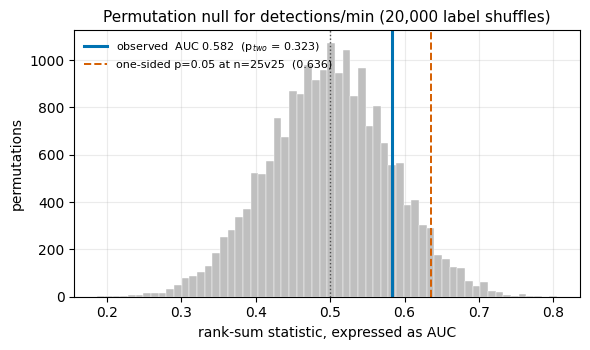

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.hist(u_null / (n1 * n0), bins=60, color='0.75', edgecolor='white', lw=.3)
ax.axvline(auc, color=COL[1], lw=2.2, label=f'observed  AUC {auc:.3f}  (p$_{{two}}$ = {p_perm_two:.3f})')
ax.axvline(auc_sig, color=COL[0], ls='--', lw=1.4, label=f'one-sided p=0.05 at n={n1}v{n0}  ({auc_sig:.3f})')
ax.axvline(.5, ls=':', color='0.3', lw=1)
ax.set_xlabel('rank-sum statistic, expressed as AUC'); ax.set_ylabel('permutations')
ax.set_title('Permutation null for detections/min (20,000 label shuffles)', fontsize=11)
ax.legend(fontsize=8, frameon=False, loc='upper left')
ax.grid(alpha=.25); ax.set_axisbelow(True)
fig.tight_layout(); fig.savefig(FIGS / 'recording_level_ranksum_null.png', dpi=800, bbox_inches='tight')
plt.show()

## 5. The distributions

Both statistics above are summaries of this picture, and the overlap *is* the finding whichever way it
falls. Points are individual recordings, jittered horizontally only; the bar is the group median.

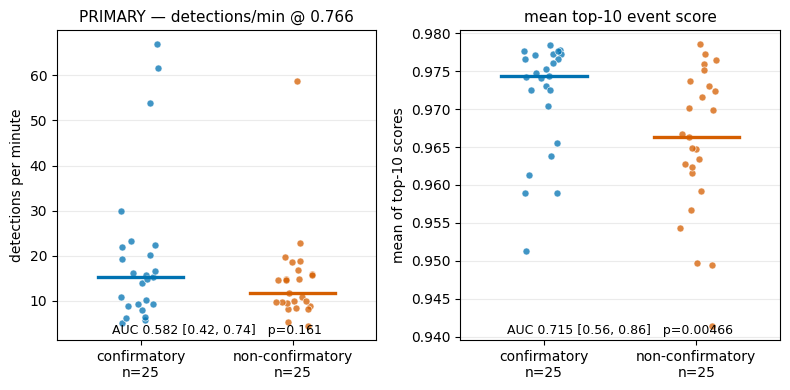

In [7]:
def strip(ax, col, title, ylabel, logy=False):
    rng = np.random.default_rng(rng_seed)
    for k, lab in enumerate((1, 0)):
        v = rec.loc[rec.label == lab, col].values
        ax.scatter(k + rng.uniform(-.13, .13, len(v)), v, s=26, alpha=.75, lw=.6,
                   color=COL[lab], edgecolor='white', zorder=3)
        ax.plot([k - .28, k + .28], [np.median(v)] * 2, color=COL[lab], lw=2.4, zorder=4)
    ax.set_xticks([0, 1]); ax.set_xticklabels([f'{NAME[1]}\nn={(y==1).sum()}', f'{NAME[0]}\nn={(y==0).sum()}'])
    ax.set_xlim(-.55, 1.55); ax.set_title(title, fontsize=11); ax.set_ylabel(ylabel)
    if logy: ax.set_yscale('log')
    ax.grid(axis='y', alpha=.25); ax.set_axisbelow(True)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
strip(axes[0], 'rate', f'PRIMARY — detections/min @ {THR}', 'detections per minute')
strip(axes[1], f'top{TOP_N}', f'mean top-{TOP_N} event score', 'mean of top-10 scores')
for ax, r in zip(axes, [summarise(rec['rate']), summarise(rec[f'top{TOP_N}'])]):
    ax.text(.5, .02, f"AUC {r['AUC']:.3f} [{r['lo']:.2f}, {r['hi']:.2f}]   p={r['p']:.3g}",
            transform=ax.transAxes, ha='center', fontsize=9)
fig.tight_layout(); fig.savefig(FIGS / 'recording_level_distributions.png', dpi=800, bbox_inches='tight')
plt.show()

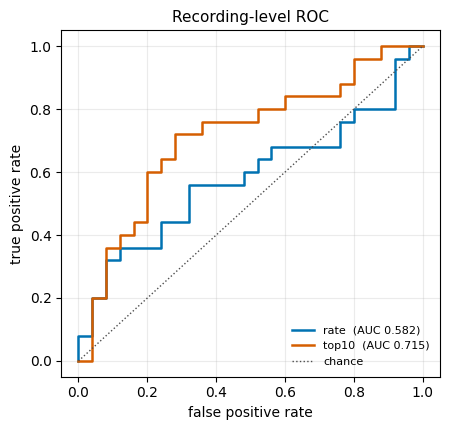

In [8]:
fig, ax = plt.subplots(figsize=(4.6, 4.4))
for col, c, ls in [('rate', COL[1], '-'), (f'top{TOP_N}', COL[0], '-')]:
    fpr, tpr, _ = roc_curve(y, rec[col])
    ax.plot(fpr, tpr, ls, color=c, lw=1.8, label=f'{col}  (AUC {roc_auc_score(y, rec[col]):.3f})')
ax.plot([0, 1], [0, 1], ':', color='0.3', lw=1, label='chance')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('Recording-level ROC', fontsize=11); ax.legend(fontsize=8, loc='lower right', frameon=False)
ax.grid(alpha=.25); ax.set_axisbelow(True)
fig.tight_layout(); fig.savefig(FIGS / 'recording_level_roc.png', dpi=800, bbox_inches='tight')
plt.show()

## 6. Threshold sensitivity

The threshold decides which events are counted, so it decides every rate and therefore the AUC. It was
fixed in advance; this section reports how much that choice mattered, as the protocol requires. If the
conclusion holds across the range, say so; if it does not, that is a finding too.

The **only** legitimate reading of this table is stability. Picking the row with the best AUC and
quoting it invalidates the result.

 threshold   AUC    lo    hi  med_conf  med_non          note
     0.500 0.597 0.433 0.756    37.397   32.069              
     0.600 0.587 0.425 0.745    27.636   23.153              
     0.700 0.598 0.439 0.754    20.304   15.961              
     0.750 0.592 0.431 0.750    16.719   12.660              
     0.766 0.582 0.419 0.741    15.212   11.773           RUN
     0.784 0.574 0.410 0.738    13.496   10.443 md doc, stale
     0.800 0.586 0.421 0.745    11.721    8.916              
     0.850 0.582 0.415 0.742     7.215    6.557              
     0.900 0.594 0.428 0.754     3.868    3.210              
     0.950 0.651 0.493 0.801     1.672    0.800              


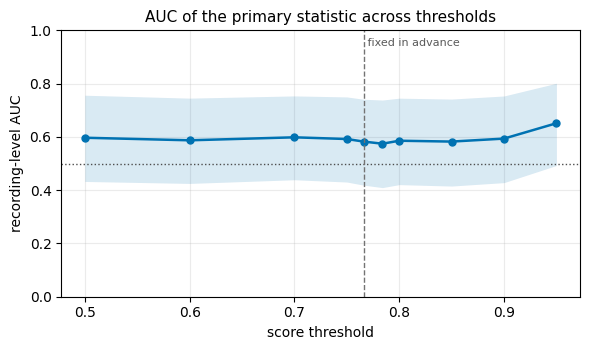

In [9]:
grid = [0.5, 0.6, 0.7, 0.75, THR, 0.784, 0.8, 0.85, 0.9, 0.95]
out = []
for t in sorted(set(grid)):
    r = np.array([n_above(f, t) for f in rec.file]) / rec.dur_min.values
    a, lo, hi = auc_ci(y, r)
    out.append(dict(threshold=t, AUC=a, lo=lo, hi=hi,
                    med_conf=np.median(r[y == 1]), med_non=np.median(r[y == 0]),
                    note='RUN' if t == THR else ('md doc, stale' if t == 0.784 else '')))
sens = pd.DataFrame(out)
print(sens.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.fill_between(sens.threshold, sens.lo, sens.hi, color=COL[1], alpha=.15, lw=0)
ax.plot(sens.threshold, sens.AUC, '-o', color=COL[1], ms=5, lw=1.8, label='detections/min')
ax.axhline(.5, ls=':', color='0.3', lw=1)
ax.axvline(THR, ls='--', color='0.45', lw=1)
ax.text(THR, .97, ' fixed in advance', color='0.35', fontsize=8, va='top', transform=ax.get_xaxis_transform())
ax.set_xlabel('score threshold'); ax.set_ylabel('recording-level AUC'); ax.set_ylim(0, 1)
ax.set_title('AUC of the primary statistic across thresholds', fontsize=11)
ax.grid(alpha=.25); ax.set_axisbelow(True)
fig.tight_layout(); fig.savefig(FIGS / 'recording_level_threshold_sensitivity.png', dpi=800, bbox_inches='tight')
plt.show()

## 7. Threats to validity

Four, in the order they can invalidate the result.

**7a. Duration.** The groups differ in length (§2). Three controls test whether that leaks into the
statistics, each with a different failure mode, so agreement between them is what counts:
1. **residualise** each statistic on log duration — over-adjusts, because duration is itself
   associated with the label, so it removes real signal along with the nuisance and reads as a *lower
   bound*;
2. **duration-matched pairs** — unbiased but throws away recordings, so it is the noisiest;
3. **truncate every recording to its first 20 minutes** and recompute from the events inside that
   window — every recording then contributes exactly the same amount of EEG, so duration cannot act at
   all. This is the cleanest control and the one to lead with, provided no recording is shorter than
   the cap (asserted).

**7b. The front end.** `events/min` counts L1+L2 candidates *before* L3 scores anything. On Kural this
sat at chance (AUC 0.511), which showed the separation was L3's doing and not "epileptic EEG produces
more transients". Same control here.

**7c. Background amplitude.** The amplitude confound (report.md §9) is the known rival explanation:
before `normalise_amplitude`, L3's scores tracked how loud a recording was. `background_uv` is exported
precisely so the check can be repeated off-Kural — as a classifier in its own right, and as a
correlate of the detector statistic.

**7d. Site and subject clustering.** Recordings are not independent if several come from one patient or
one site. Filenames encode both (`S06_001_EEG_003.edf` → site `S06`, subject `S06_001`). If a site
appears in only one group, acquisition differences are perfectly confounded with the label. Three
reads: a subject-level (cluster) bootstrap, the analysis restricted to sites present in both groups,
and per-site AUCs.

**7e. Negative-group contamination**, which cannot be tested from these CSVs and must be stated: if
"non-confirmatory" means the clinical report did not mention IEDs, some of those recordings may contain
unreported discharges. Contamination biases toward the null — a positive result survives it, a null
result is harder to interpret.

In [10]:
print('7a. DURATION  ' + '-' * 60)
ld = np.log(rec.duration_s.values)
CAP = 1200.0   # 20 min
assert rec.duration_s.min() >= CAP, 'a recording is shorter than the cap; truncation control invalid'
capped = {f: np.sort(g.loc[g.time_s <= CAP, 'score'].values)[::-1] for f, g in ev.groupby('file')}

cols = ['rate', f'top{TOP_N}', 'top5', 'background_uv']
d = rec.duration_s.values
pos, neg = list(np.where(y == 1)[0]), list(np.where(y == 0)[0])
pairs = []
for i in sorted(pos, key=lambda i: d[i]):
    if not neg: break
    j = min(neg, key=lambda j: abs(d[j] - d[i]))
    if abs(d[j] - d[i]) < 180:
        pairs.append(i); pairs.append(j); neg.remove(j)
m = rec.iloc[pairs]
print(f"matched subsample: {len(pairs)//2} pairs, duration AUC {roc_auc_score(m.label, m.duration_s):.3f} "
      f"(was {roc_auc_score(y, rec.duration_s):.3f})")

print(f"\n{'statistic':>16} {'raw':>18} {'resid. log dur':>15} {'matched pairs':>14} {'first 20 min':>26}")
for c in cols:
    x = rec[c].values.astype(float)
    res = x - np.polyval(np.polyfit(ld, x, 1), ld)
    if c == 'rate':
        t = np.array([(capped[f] >= THR).sum() for f in rec.file]) / (CAP / 60)
    elif c.startswith('top'):
        n = int(c[3:]); t = np.array([capped[f][:n].mean() for f in rec.file])
    else:
        t = np.full(len(rec), np.nan)
    a, lo, hi = auc_ci(y, x)
    tt = f"{roc_auc_score(y, t):.3f} {np.round(auc_ci(y, t)[1:], 2)}" if np.isfinite(t).all() else 'n/a (not event-based)'
    print(f"{c:>16} {a:.3f} [{lo:.2f},{hi:.2f}] {roc_auc_score(y, res):>15.3f} "
          f"{roc_auc_score(m.label, m[c]):>14.3f}  {tt:>25}")
print("\nrho(duration, statistic):",
      {c: round(spearmanr(rec.duration_s, rec[c]).statistic, 3) for c in cols + ['n_events']})

7a. DURATION  ------------------------------------------------------------
matched subsample: 14 pairs, duration AUC 0.497 (was 0.796)

       statistic                raw  resid. log dur  matched pairs               first 20 min


            rate 0.582 [0.42,0.74]           0.382          0.439          0.558 [0.4  0.72]


           top10 0.715 [0.56,0.86]           0.622          0.566          0.690 [0.53 0.83]


            top5 0.726 [0.58,0.86]           0.630          0.582          0.722 [0.57 0.86]


   background_uv 0.640 [0.48,0.79]           0.490          0.520      n/a (not event-based)

rho(duration, statistic): {'rate': 0.212, 'top10': 0.484, 'top5': 0.476, 'background_uv': 0.358, 'n_events': 0.708}


In [11]:
print('7b. FRONT END (L1+L2, before L3 scores anything)  ' + '-' * 26)
for c in ['cand_min', 'events_min', 'n_events']:
    r = summarise(rec[c], c)
    print(f"{c:>12}  AUC {r['AUC']:.3f} [{r['lo']:.3f}, {r['hi']:.3f}]  p {r['p']:.3g}   "
          f"median {r['med_conf']:.1f} vs {r['med_non']:.1f}")
print('   (n_events is a raw count and inherits the duration effect; events_min is the control)')

print('\n7c. BACKGROUND AMPLITUDE  ' + '-' * 48)
r = summarise(rec.background_uv, 'background_uv')
print(f"  amplitude alone : AUC {r['AUC']:.3f} [{r['lo']:.3f}, {r['hi']:.3f}]  p {r['p']:.3g}   "
      f"median {r['med_conf']:.2f} vs {r['med_non']:.2f} uV")
for c in ['rate', f'top{TOP_N}']:
    s = spearmanr(rec.background_uv, rec[c])
    print(f"  rho(amplitude, {c:<7}) = {s.statistic:+.3f}   p {s.pvalue:.3g}"
          f"      [Kural, pre-normalisation: +0.708; post: +0.060]")

7b. FRONT END (L1+L2, before L3 scores anything)  --------------------------


    cand_min  AUC 0.554 [0.388, 0.717]  p 0.261   median 1688.2 vs 1689.6


  events_min  AUC 0.483 [0.314, 0.644]  p 0.585   median 251.3 vs 253.9


    n_events  AUC 0.773 [0.630, 0.889]  p 0.000486   median 6180.0 vs 5255.0
   (n_events is a raw count and inherits the duration effect; events_min is the control)

7c. BACKGROUND AMPLITUDE  ------------------------------------------------


  amplitude alone : AUC 0.640 [0.477, 0.792]  p 0.0457   median 6.17 vs 5.64 uV
  rho(amplitude, rate   ) = +0.161   p 0.263      [Kural, pre-normalisation: +0.708; post: +0.060]
  rho(amplitude, top10  ) = +0.354   p 0.0116      [Kural, pre-normalisation: +0.708; post: +0.060]


In [12]:
print('7d. SITE AND SUBJECT CLUSTERING  ' + '-' * 42)
print(pd.crosstab(rec.site, rec.label.map(NAME)).to_string())
multi = rec.groupby('subject').size().pipe(lambda s: s[s > 1])
print(f"\nsubjects contributing >1 recording: {dict(multi)}")

def boot_cluster(col, n=BOOT, seed=rng_seed):
    '''Bootstrap over SUBJECTS, not recordings.'''
    rng = np.random.default_rng(seed)
    idx = [g.index.values for _, g in rec.groupby('subject')]
    x = rec[col].values.astype(float); b = []
    for _ in range(n):
        i = np.concatenate([idx[k] for k in rng.integers(0, len(idx), len(idx))])
        if len(np.unique(y[i])) < 2:
            continue
        b.append(roc_auc_score(y[i], x[i]))
    return np.percentile(b, [2.5, 97.5])

shared = rec[rec.site.isin(set(rec.loc[y == 1, 'site']) & set(rec.loc[y == 0, 'site']))]
big = multi.idxmax() if len(multi) else None
drop = rec[rec.subject != big]
print(f"\n{'statistic':>14} {'all (rec. boot)':>22} {'all (subject boot)':>20} "
      f"{'shared sites n=%d' % len(shared):>19} {'drop %s n=%d' % (big, len(drop)):>21}")
for c in ['rate', f'top{TOP_N}', 'background_uv']:
    a, lo, hi = auc_ci(y, rec[c])
    clo, chi = boot_cluster(c)
    print(f"{c:>14} {a:.3f} [{lo:.2f},{hi:.2f}] {'[%.2f,%.2f]' % (clo, chi):>20} "
          f"{roc_auc_score(shared.label, shared[c]):>19.3f} {roc_auc_score(drop.label, drop[c]):>21.3f}")

print('\nper-site AUC (sites present in both groups):')
for s, g in shared.groupby('site'):
    print(f"  {s}  n={len(g):2d} ({(g.label==1).sum()} conf)  " +
          '  '.join(f"{c} {roc_auc_score(g.label, g[c]):.3f}" for c in ['rate', f'top{TOP_N}']))

7d. SITE AND SUBJECT CLUSTERING  ------------------------------------------
label  confirmatory  non-confirmatory
site                                 
S01               5                 7
S02               0                 6
S06               9                 0
S07               6                 6
S08               5                 6

subjects contributing >1 recording: {'S06_001': 9}

     statistic        all (rec. boot)   all (subject boot)   shared sites n=35     drop S06_001 n=41


          rate 0.582 [0.42,0.74]          [0.41,0.72]               0.553                 0.552


         top10 0.715 [0.56,0.86]          [0.55,0.84]               0.688                 0.698


 background_uv 0.640 [0.48,0.79]          [0.43,0.78]               0.572                 0.570

per-site AUC (sites present in both groups):
  S01  n=12 (5 conf)  rate 0.600  top10 0.514
  S07  n=12 (6 conf)  rate 0.500  top10 0.806
  S08  n=11 (5 conf)  rate 0.500  top10 0.800


## 8. Exploratory summaries

Every other one-number-per-recording summary the CSVs support, so that the two pre-registered choices
can be read in context. **These are exploratory.** Ten-odd statistics on the same recordings means the
best of them is optimistic by a few points of AUC, exactly as on the Kural pilot pre-test (report.md
§9), and none of them may be promoted to the headline after the fact.

    statistic    AUC     lo     hi    r_rb      p  med_conf  med_non
         top5 0.7264 0.5789 0.8633  0.4528 0.0031    0.9761   0.9717
         top3 0.7216 0.5730 0.8606  0.4432 0.0037    0.9773   0.9730
        top10 0.7152 0.5632 0.8583  0.4304 0.0047    0.9744   0.9664
        top20 0.6752 0.5195 0.8245  0.3504 0.0172    0.9709   0.9610
  n_above_0.5 0.6720 0.5146 0.8181  0.3440 0.0189  812.0000 662.0000
         top1 0.6648 0.5056 0.8221  0.3296 0.0233    0.9778   0.9747
background_uv 0.6400 0.4766 0.7923  0.2800 0.0457    6.1700   5.6375
  n_above_0.7 0.6352 0.4792 0.7829  0.2704 0.0516  445.0000 330.0000
  n_above_0.9 0.6224 0.4602 0.7773  0.2448 0.0701   94.0000  68.0000
        top50 0.6080 0.4444 0.7649  0.2160 0.0968    0.9596   0.9415
          q95 0.5984 0.4333 0.7568  0.1968 0.1183    0.7890   0.7425
   p99_abs_uv 0.5952 0.4288 0.7488  0.1904 0.1262  108.2781  79.5224
         rate 0.5824 0.4188 0.7413  0.1648 0.1612   15.2120  11.7734
          q90 0.5792 0.4138 0.7388

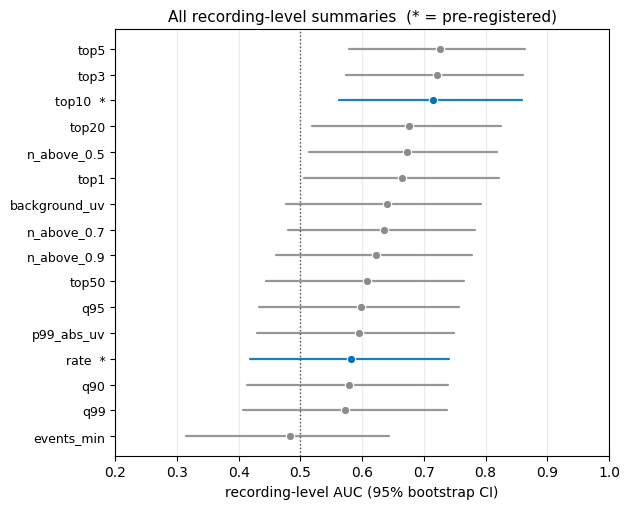

In [13]:
expl = ['rate', 'top1', 'top3', 'top5', f'top{TOP_N}', 'top20', 'top50',
        'q90', 'q95', 'q99', 'n_above_0.5', 'n_above_0.7', 'n_above_0.9',
        'events_min', 'background_uv', 'p99_abs_uv']
tab = pd.DataFrame([summarise(rec[c], c) for c in expl]).sort_values('AUC', ascending=False)
print(tab.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

fig, ax = plt.subplots(figsize=(6.4, 5.2))
t = tab.iloc[::-1]
pre = {'rate', f'top{TOP_N}'}
for i, r in enumerate(t.itertuples()):
    c = COL[1] if r.statistic in pre else '0.55'
    ax.plot([r.lo, r.hi], [i, i], color=c, lw=1.6, alpha=.9, solid_capstyle='round')
    ax.plot(r.AUC, i, 'o', color=c, ms=6, mec='white', mew=.8, zorder=3)
ax.axvline(.5, ls=':', color='0.3', lw=1)
ax.set_yticks(range(len(t)))
ax.set_yticklabels([f"{s}{'  *' if s in pre else ''}" for s in t.statistic], fontsize=9)
ax.set_xlabel('recording-level AUC (95% bootstrap CI)'); ax.set_xlim(0.2, 1)
ax.set_title('All recording-level summaries  (* = pre-registered)', fontsize=11)
ax.grid(axis='x', alpha=.25); ax.set_axisbelow(True)
fig.tight_layout(); fig.savefig(FIGS / 'recording_level_all_statistics.png', dpi=800, bbox_inches='tight')
plt.show()

## 9. Sub-analysis — epilepsy diagnosis inside the non-confirmatory group

The supervisor supplied a **second, different label** for the non-confirmatory recordings: whether the
patient has epilepsy (E) or not (N). These are the recordings judged to contain no IEDs, so this asks a
question the main analysis cannot:

> among recordings with no discharges to find, does the detection rate still tell an epileptic patient
> from a non-epileptic one?

A positive answer would mean the detector responds to something about epileptic EEG **other than
discharges** — the correlate-confound named in the header, and the same ambiguity as report.md §7 Q4
(epileptic background genuinely more IED-like, versus unmarked discharges the report did not record). A
null answer is the more reassuring one for the localisation claim.

Two threats to read the result against:

- **Power.** 11 vs 12 recordings. The rank-sum test cannot reach p < 0.05 below AUC ≈ 0.70, and needs a
  true AUC near 0.81 for 80% power — so this can only detect a large effect, and a null here means *no
  evidence of*, never *evidence of no*.
- **Two recordings are unlabelled** (no entry supplied) and are dropped rather than guessed; the cell
  prints which.

The informative comparison is the three-way one at the end: if `mean top-10` separates confirmatory
recordings from non-confirmatory **E** and **N** by the same margin, then what it detects tracks IED
presence rather than the epilepsy diagnosis.

In [14]:
EPI = {'1_9': 'E', '1_11': 'N', '1_14': 'N', '1_15': 'E', '1_16': 'E', '1_20': 'E', '1_36': 'E',
       '2_3': 'E', '2_5': 'N', '2_7': 'E', '2_11': 'N', '2_15': 'N',
       '7_65': 'E', '7_78': 'E', '7_82': 'N', '7_84': 'N', '7_88': 'N', '7_98': 'E',
       '8_2': 'N', '8_5': 'N', '8_7': 'N', '8_9': 'N', '8_21': 'E'}

nc = rec[rec.label == 0].copy()
p = nc.file.str.extract(r'S0(\d)_0*(\d+)')
nc['epi'] = (p[0] + '_' + p[1]).map(EPI)
print('unlabelled, dropped :', nc.loc[nc.epi.isna(), 'file'].tolist())
sub = nc.dropna(subset=['epi'])
ye = (sub.epi == 'E').astype(int).values
nE, nN = int(ye.sum()), int((1 - ye).sum())
print(f'labelled            : {nE} epileptic, {nN} non-epileptic')

print(f"\n{'statistic':>14} {'AUC':>6} {'95% CI':>16} {'p 2-sided':>10} {'p 1-sided':>10}   median E / N")
for c in ['rate', f'top{TOP_N}', 'top5', 'top1', 'background_uv', 'events_min']:
    x = sub[c].values.astype(float)
    a, lo, hi = auc_ci(ye, x)
    print(f"{c:>14} {a:6.3f} [{lo:.3f},{hi:.3f}] "
          f"{mannwhitneyu(x[ye == 1], x[ye == 0], alternative='two-sided').pvalue:10.4f} "
          f"{mannwhitneyu(x[ye == 1], x[ye == 0], alternative='greater').pvalue:10.4f}   "
          f"{np.median(x[ye == 1]):.3f} / {np.median(x[ye == 0]):.3f}")

se0 = np.sqrt((nE + nN + 1) / (12 * nE * nN))
print(f"\nat {nE} vs {nN}: smallest AUC reaching one-sided p<0.05 = {0.5 + 1.6449 * se0:.3f}, "
      f"true AUC for 80% power = {0.5 + 2.4865 * se0:.3f}")

conf = rec[rec.label == 1]
print('\nthree-way — is the group signal about IEDs, or about the diagnosis?')
for c in ['rate', f'top{TOP_N}']:
    for g, s in (('E', ye == 1), ('N', ye == 0)):
        v = np.r_[conf[c].values, sub.loc[s, c].values]
        print(f"  confirmatory vs non-confirmatory {g}   {c:>5}  AUC "
              f"{roc_auc_score([1] * len(conf) + [0] * int(s.sum()), v):.3f}")

unlabelled, dropped : ['S02_006_EEG_01.EDF', 'S08_008_EEG_01.edf']
labelled            : 11 epileptic, 12 non-epileptic

     statistic    AUC           95% CI  p 2-sided  p 1-sided   median E / N


          rate  0.515 [0.265,0.758]     0.9264     0.4632   14.709 / 11.265


         top10  0.561 [0.308,0.802]     0.6444     0.3222   0.970 / 0.965


          top5  0.583 [0.333,0.818]     0.5181     0.2591   0.973 / 0.971


          top1  0.561 [0.304,0.800]     0.6443     0.3221   0.976 / 0.975


 background_uv  0.364 [0.131,0.617]     0.2815     0.8726   5.411 / 6.278


    events_min  0.598 [0.348,0.833]     0.4417     0.2209   254.648 / 249.991

at 11 vs 12: smallest AUC reaching one-sided p<0.05 = 0.702, true AUC for 80% power = 0.806

three-way — is the group signal about IEDs, or about the diagnosis?
  confirmatory vs non-confirmatory E    rate  AUC 0.585
  confirmatory vs non-confirmatory N    rate  AUC 0.590
  confirmatory vs non-confirmatory E   top10  AUC 0.702
  confirmatory vs non-confirmatory N   top10  AUC 0.690


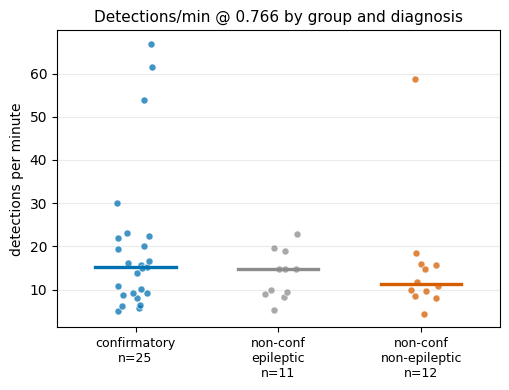

In [15]:
fig, ax = plt.subplots(figsize=(5.2, 4))
gen = np.random.default_rng(rng_seed)
groups = [('confirmatory', conf['rate'].values, COL[1]),
          ('non-conf\nepileptic', sub.loc[ye == 1, 'rate'].values, '0.55'),
          ('non-conf\nnon-epileptic', sub.loc[ye == 0, 'rate'].values, COL[0])]
for k, (nm, v, c) in enumerate(groups):
    ax.scatter(k + gen.uniform(-.13, .13, len(v)), v, s=26, alpha=.75, lw=.6,
               color=c, edgecolor='white', zorder=3)
    ax.plot([k - .28, k + .28], [np.median(v)] * 2, color=c, lw=2.4, zorder=4)
ax.set_xticks(range(3)); ax.set_xticklabels([f'{nm}\nn={len(v)}' for nm, v, _ in groups], fontsize=9)
ax.set_xlim(-.55, 2.55); ax.set_ylabel('detections per minute')
ax.set_title(f'Detections/min @ {THR} by group and diagnosis', fontsize=11)
ax.grid(axis='y', alpha=.25); ax.set_axisbelow(True)
fig.tight_layout(); fig.savefig(FIGS / 'recording_level_epilepsy_subgroup.png', dpi=800, bbox_inches='tight')
plt.show()

## 10. Detections per minute across FP budgets, three groups

The rate is the quantity with a clinical meaning — how much a reader is asked to look at — and unlike the
AUC it survives being quoted on its own. This section reports it for all three groups across the
operating range.

**The FP budget can be read off this data directly, which Kural could never do.** The `non-conf N`
recordings have no IEDs *and* no epilepsy, so every detection in them is a false positive by
construction. Their detections/min at a given threshold **is** the empirical FP rate. So instead of
importing Kural's budget-to-threshold mapping — which was calibrated on 11–14 s clips and has no reason
to transfer — each budget below is inverted on these recordings: find the threshold whose median rate in
`non-conf N` equals the target, then read all three groups at that threshold. The row at Kural's own
0.766 shows how far the imported calibration lands from the external one.

**Median, not mean.** The rate distribution has a long right tail (a handful of recordings run 3-4× the
group's typical rate), and at the fixed threshold the means are non-monotone while the medians are not —
the mean is reporting the outliers, not the group.

**The hypothesis is ordered**, not just "the groups differ": IEDs present > epilepsy but no IEDs recorded
> no epilepsy. Kruskal-Wallis throws that ordering away and tests only for *some* difference, so the
test here is **Jonckheere-Terpstra** — the sum of pairwise Mann-Whitney statistics across the ordered
groups, with a permutation null. It is the more powerful test when the direction is predicted in advance,
and the direction was.

In [16]:
assert (rec.index.values == np.arange(len(rec))).all()
G3 = {'non-conf N': sub.index[ye == 0].values,      # ordered ascending under the trend hypothesis
      'non-conf E': sub.index[ye == 1].values,
      'confirmatory': conf.index.values}
mask = {g: np.isin(np.arange(len(rec)), i) for g, i in G3.items()}
rate_at = lambda t: np.array([n_above(f, t) for f in rec.file]) / rec.dur_min.values

def jt(r, B=5000, seed=rng_seed):
    '''Jonckheere-Terpstra trend statistic and permutation p for the ordered alternative.'''
    stat = lambda gs: sum(mannwhitneyu(gs[j], gs[i], alternative='two-sided').statistic
                          for i in range(len(gs)) for j in range(i + 1, len(gs)))
    keep = np.concatenate(list(G3.values()))
    sizes = [len(i) for i in G3.values()]
    obs = stat([r[i] for i in G3.values()])
    rng = np.random.default_rng(seed)
    null = np.empty(B)
    for b in range(B):
        s, o, c = rng.permutation(r[keep]), 0, []
        for n in sizes:
            c.append(s[o:o + n]); o += n
        null[b] = stat(c)
    return obs, float(np.mean(null >= obs))

grid = np.arange(0.30, 0.9995, 0.0005)
med_fp = np.array([np.median(rate_at(t)[mask['non-conf N']]) for t in grid])

print(f"detections/min, median [IQR] — FP budget calibrated on non-conf N (no IEDs, no epilepsy)\n")
print(f"{'FP budget':>9} {'thr':>7} | " + ' | '.join(f'{g:>21}' for g in G3) + f" | {'C/N':>5} | {'JT p':>6}")
rows = []
for b in [1, 2, 5, 10, 25, 50, None]:
    t = THR if b is None else grid[int(np.argmin(np.abs(med_fp - b)))]
    r = rate_at(t)
    med = {g: np.median(r[mask[g]]) for g in G3}
    cells = ' | '.join(f"{med[g]:6.2f} [{np.percentile(r[mask[g]], 25):5.2f},{np.percentile(r[mask[g]], 75):6.2f}]"
                       for g in G3)
    tag = f'{b:9}' if b is not None else '   KURAL '
    print(f"{tag} {t:7.4f} | {cells} | {med['confirmatory'] / med['non-conf N']:5.2f} | {jt(r)[1]:6.3f}")
    rows.append(dict(budget=b, thr=t, **med))
budgets = pd.DataFrame(rows)

t10 = grid[int(np.argmin(np.abs(med_fp - 10)))]
print(f"\ntransfer of the operating point:")
print(f"  Kural's <=10 FP/min threshold is {THR}; externally it delivers "
      f"{np.median(rate_at(THR)[mask['non-conf N']]):.2f} FP/min")
print(f"  10 FP/min on THIS data needs threshold {t10:.4f}")
print(f"\nmeans at {THR} (outlier-driven, non-monotone — shown to justify using the median): " +
      ', '.join(f"{g} {rate_at(THR)[mask[g]].mean():.2f}" for g in G3))

detections/min, median [IQR] — FP budget calibrated on non-conf N (no IEDs, no epilepsy)

FP budget     thr |            non-conf N |            non-conf E |          confirmatory |   C/N |   JT p


        1  0.9420 |   0.98 [ 0.77,  3.07] |   1.48 [ 0.72,  2.31] |   2.06 [ 0.80,  4.73] |  2.10 |  0.123


        2  0.9235 |   2.01 [ 1.49,  4.46] |   2.37 [ 1.32,  3.19] |   2.99 [ 1.21,  6.28] |  1.49 |  0.152


        5  0.8750 |   5.00 [ 3.83,  7.59] |   5.43 [ 2.90,  6.81] |   5.72 [ 2.71, 10.57] |  1.14 |  0.258


       10  0.7890 |  10.00 [ 8.23, 13.99] |  12.05 [ 7.65, 14.82] |  12.87 [ 7.16, 19.58] |  1.29 |  0.179


       25  0.5630 |  25.02 [20.81, 28.74] |  27.55 [21.41, 31.88] |  30.76 [23.01, 40.11] |  1.23 |  0.104


       50  0.3615 |  50.02 [42.34, 53.10] |  52.50 [42.99, 59.60] |  57.25 [40.18, 71.34] |  1.14 |  0.159


   KURAL   0.7660 |  11.27 [ 9.41, 15.85] |  14.71 [ 9.19, 16.85] |  15.21 [ 9.21, 21.94] |  1.35 |  0.153

transfer of the operating point:
  Kural's <=10 FP/min threshold is 0.766; externally it delivers 11.27 FP/min
  10 FP/min on THIS data needs threshold 0.7890

means at 0.766 (outlier-driven, non-monotone — shown to justify using the median): non-conf N 15.59, non-conf E 13.39, confirmatory 19.66


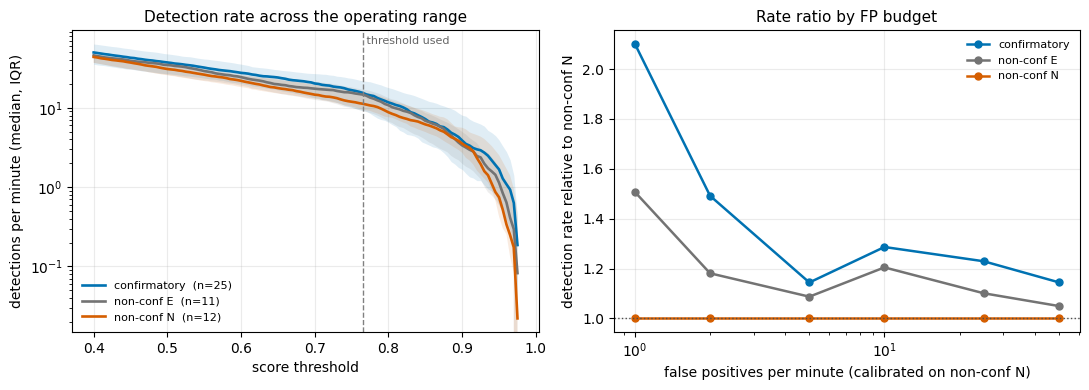

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ts = np.arange(0.40, 0.978, 0.005)
CG = {'confirmatory': COL[1], 'non-conf E': '0.45', 'non-conf N': COL[0]}
curves = {g: np.array([[np.percentile(rate_at(t)[mask[g]], q) for q in (25, 50, 75)] for t in ts])
          for g in G3}
for g, c in CG.items():
    axes[0].fill_between(ts, curves[g][:, 0], curves[g][:, 2], color=c, alpha=.12, lw=0)
    axes[0].plot(ts, curves[g][:, 1], color=c, lw=1.9, label=f'{g}  (n={mask[g].sum()})')
axes[0].axvline(THR, ls='--', color='0.5', lw=1)
axes[0].text(THR, .98, ' threshold used', color='0.4', fontsize=8, va='top',
             transform=axes[0].get_xaxis_transform())
axes[0].set_yscale('log'); axes[0].set_xlabel('score threshold')
axes[0].set_ylabel('detections per minute (median, IQR)')
axes[0].set_title('Detection rate across the operating range', fontsize=11)
axes[0].legend(fontsize=8, frameon=False)

bl = budgets.dropna(subset=['budget'])
for g, c in CG.items():
    axes[1].plot(bl.budget, bl[g] / bl['non-conf N'], '-o', color=c, ms=5, lw=1.8, label=g)
axes[1].axhline(1, ls=':', color='0.3', lw=1)
axes[1].set_xscale('log'); axes[1].set_xlabel('false positives per minute (calibrated on non-conf N)')
axes[1].set_ylabel('detection rate relative to non-conf N')
axes[1].set_title('Rate ratio by FP budget', fontsize=11)
axes[1].legend(fontsize=8, frameon=False)
for ax in axes:
    ax.grid(alpha=.25); ax.set_axisbelow(True)
fig.tight_layout(); fig.savefig(FIGS / 'recording_level_fp_budgets.png', dpi=800, bbox_inches='tight')
plt.show()

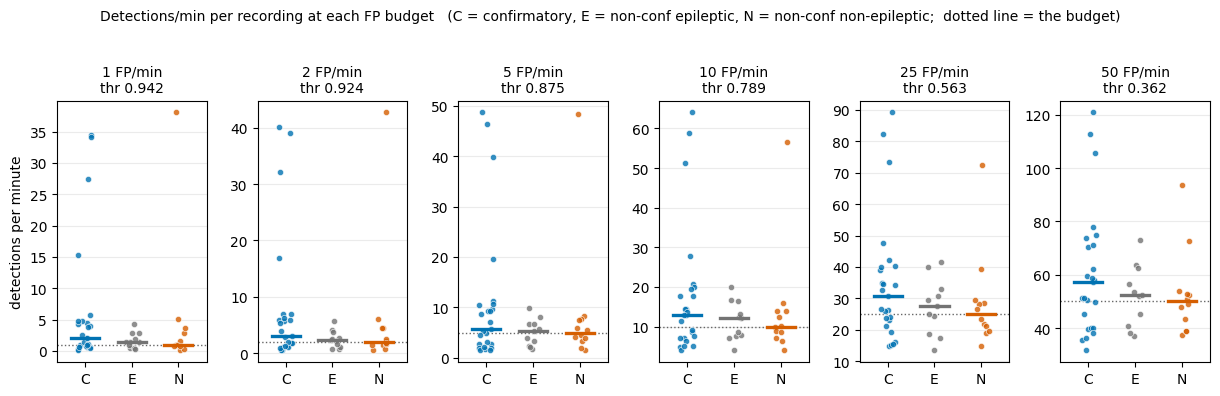

In [18]:
show = [b for b in budgets.budget if b is not None and not pd.isna(b)]
fig, axes = plt.subplots(1, len(show), figsize=(2.05 * len(show), 4.0))
gen = np.random.default_rng(rng_seed)
CG = {'confirmatory': COL[1], 'non-conf E': '0.45', 'non-conf N': COL[0]}
order = ['confirmatory', 'non-conf E', 'non-conf N']

for ax, b in zip(axes, show):
    t = float(budgets.loc[budgets.budget == b, 'thr'].iloc[0])
    r = rate_at(t)
    for k, g in enumerate(order):
        v = r[mask[g]]
        ax.scatter(k + gen.uniform(-.16, .16, len(v)), v, s=20, alpha=.8, lw=.5,
                   color=CG[g], edgecolor='white', zorder=3)
        ax.plot([k - .3, k + .3], [np.median(v)] * 2, color=CG[g], lw=2.4, zorder=4)
    ax.axhline(b, ls=':', color='0.4', lw=1, zorder=1)
    ax.set_xticks(range(3)); ax.set_xticklabels(['C', 'E', 'N'])
    ax.set_xlim(-.6, 2.6)
    ax.set_title(f'{b:g} FP/min\nthr {t:.3f}', fontsize=10)
    ax.grid(axis='y', alpha=.25); ax.set_axisbelow(True)
axes[0].set_ylabel('detections per minute')
fig.suptitle('Detections/min per recording at each FP budget   '
             '(C = confirmatory, E = non-conf epileptic, N = non-conf non-epileptic;  '
             'dotted line = the budget)', fontsize=10)
fig.tight_layout(rect=(0, 0, 1, .95))
fig.savefig(FIGS / 'recording_level_fp_budget_strips.png', dpi=800, bbox_inches='tight')
plt.show()

## 11. The best-separating FP budget — and the price of having looked for it

`recording_level_evaluation.md` says plainly: *"Do not select the threshold that maximises separation —
that invalidates the result."* Searching 338 operating points and quoting the winner's p-value and CI as
if one point had been fixed in advance is the classic way to manufacture a positive. So the search is run,
but the selection is **paid for** rather than hidden, and three numbers are reported instead of one:

- **Naive** — the AUC, CI and p at the winning budget, computed as if it had been pre-registered. These
  are the numbers that must *not* be quoted alone.
- **Selection-corrected p — a max-statistic permutation test.** Shuffle the group labels, recompute the
  AUC at every budget on the grid, and keep only the **maximum**. Two thousand shuffles give the null
  distribution of *the best AUC anyone would find by searching this grid on data with no group
  difference*. Comparing the observed maximum against that null is a valid test of "is the best budget's
  separation more than the search itself would produce". It needs no correction afterwards — the
  multiplicity is already inside the null.
- **Stability of the selection.** Bootstrap the recordings, re-run the whole search each time, and record
  which budget wins. If the argmax scatters across the range, "best at X FP/min" is noise dressed as a
  finding; if resamples keep landing in one region, the region is real even when the exact point is not.

The pre-registered operating point stays the headline result in §3. This section is an **exploratory
secondary analysis** and has to be labelled that way in the writeup, with the corrected p — not the naive
one — as its number.

In [19]:
from scipy.stats import rankdata

asc = {f: np.sort(g.score.values) for f, g in ev.groupby('file')}
ts = np.round(np.arange(0.30, 0.9760, 0.002), 4)
Rm = np.array([[(len(asc[f]) - np.searchsorted(asc[f], t, 'left')) / d
                for t in ts] for f, d in zip(rec.file, rec.dur_min)])
fp = np.median(Rm[mask['non-conf N']], axis=0)          # empirical FP/min, calibrated as in section 10
rk = rankdata(Rm, axis=0)
mC = y == 1
n1, n0 = int(mC.sum()), int((~mC).sum())
aucs = (rk[mC].sum(0) - n1 * (n1 + 1) / 2) / (n1 * n0)
k = int(np.argmax(aucs))
x = Rm[:, k]

pre = int(np.argmin(abs(ts - THR)))
print(f"grid: {len(ts)} operating points, FP/min {fp.min():.2f}-{fp.max():.2f}\n")
print(f"BEST      threshold {ts[k]:.4f}  FP budget {fp[k]:.2f}/min  AUC {aucs[k]:.3f}")
print(f"PRE-REG   threshold {THR}  FP budget {fp[pre]:.2f}/min  AUC {aucs[pre]:.3f}")
print(f"\nmedian detections/min at the best budget: "
      + ' | '.join(f"{g} {np.median(x[mask[g]]):.2f}" for g in G3))
print(f"  confirmatory {np.median(x[mC]):.2f}  vs  all non-confirmatory {np.median(x[~mC]):.2f}")

a, lo, hi = auc_ci(mC.astype(int), x)
print(f"\nNAIVE (as if pre-registered — do not quote alone)")
print(f"  AUC {a:.3f}  bootstrap 95% CI [{lo:.3f}, {hi:.3f}]")
print(f"  Mann-Whitney one-sided p {mannwhitneyu(x[mC], x[~mC], alternative='greater').pvalue:.4f}")

B = 2000
rng = np.random.default_rng(1)
mx = np.array([( (rk[rng.permutation(len(rec))[:n1]].sum(0) - n1 * (n1 + 1) / 2) / (n1 * n0) ).max()
               for _ in range(B)])
print(f"\nSELECTION-CORRECTED (max-statistic permutation, {B} shuffles)")
print(f"  null best-of-grid AUC: mean {mx.mean():.3f}, 95th pct {np.percentile(mx, 95):.3f}  "
      f"(a true 0.5 searched over this grid already reads {mx.mean():.3f})")
print(f"  corrected p = {np.mean(mx >= aucs[k]):.4f}")
print(f"  optimism of the search = {aucs[k] - (mx.mean() - 0.5) - 0.5:.3f} AUC after subtracting it")

rng = np.random.default_rng(2)
sel = []
for _ in range(2000):
    i = rng.integers(0, len(rec), len(rec))
    if len(np.unique(mC[i])) < 2:
        continue
    c = mC[i]
    rr = rankdata(Rm[i], axis=0)
    sel.append(fp[int(np.argmax((rr[c].sum(0) - c.sum() * (c.sum() + 1) / 2) / (c.sum() * (~c).sum())))])
sel = np.array(sel)
print(f"\nSTABILITY of the selected budget ({len(sel)} bootstrap searches)")
print(f"  selected FP/min: median {np.median(sel):.2f}, 95% range "
      f"[{np.percentile(sel, 2.5):.2f}, {np.percentile(sel, 97.5):.2f}]")
for lo_, hi_ in [(0, 1), (1, 3), (3, 8), (8, 20), (20, 100)]:
    print(f"    {lo_:3g}-{hi_:3g} FP/min selected in {np.mean((sel >= lo_) & (sel < hi_)):5.1%} of resamples")

print(f"\ntop 8 operating points by AUC (all in the same region = a coherent optimum, not a spike):")
for j in np.argsort(aucs)[::-1][:8]:
    print(f"   thr {ts[j]:.4f}   FP {fp[j]:6.2f}/min   AUC {aucs[j]:.3f}")

grid: 338 operating points, FP/min 0.07-61.72

BEST      threshold 0.9620  FP budget 0.30/min  AUC 0.685
PRE-REG   threshold 0.766  FP budget 11.27/min  AUC 0.582

median detections/min at the best budget: non-conf N 0.30 | non-conf E 0.53 | confirmatory 1.04
  confirmatory 1.04  vs  all non-confirmatory 0.37



NAIVE (as if pre-registered — do not quote alone)
  AUC 0.685  bootstrap 95% CI [0.531, 0.829]
  Mann-Whitney one-sided p 0.0128

SELECTION-CORRECTED (max-statistic permutation, 2000 shuffles)
  null best-of-grid AUC: mean 0.562, 95th pct 0.681  (a true 0.5 searched over this grid already reads 0.562)
  corrected p = 0.0455
  optimism of the search = 0.123 AUC after subtracting it



STABILITY of the selected budget (2000 bootstrap searches)
  selected FP/min: median 0.22, 95% range [0.07, 47.75]
      0-  1 FP/min selected in 82.0% of resamples
      1-  3 FP/min selected in  0.7% of resamples
      3-  8 FP/min selected in  1.1% of resamples
      8- 20 FP/min selected in  4.4% of resamples
     20-100 FP/min selected in 11.8% of resamples

top 8 operating points by AUC (all in the same region = a coherent optimum, not a spike):
   thr 0.9660   FP   0.22/min   AUC 0.685
   thr 0.9620   FP   0.30/min   AUC 0.685
   thr 0.9720   FP   0.10/min   AUC 0.682
   thr 0.9580   FP   0.37/min   AUC 0.677
   thr 0.9600   FP   0.34/min   AUC 0.675
   thr 0.9700   FP   0.17/min   AUC 0.670
   thr 0.9640   FP   0.30/min   AUC 0.669
   thr 0.9740   FP   0.07/min   AUC 0.667


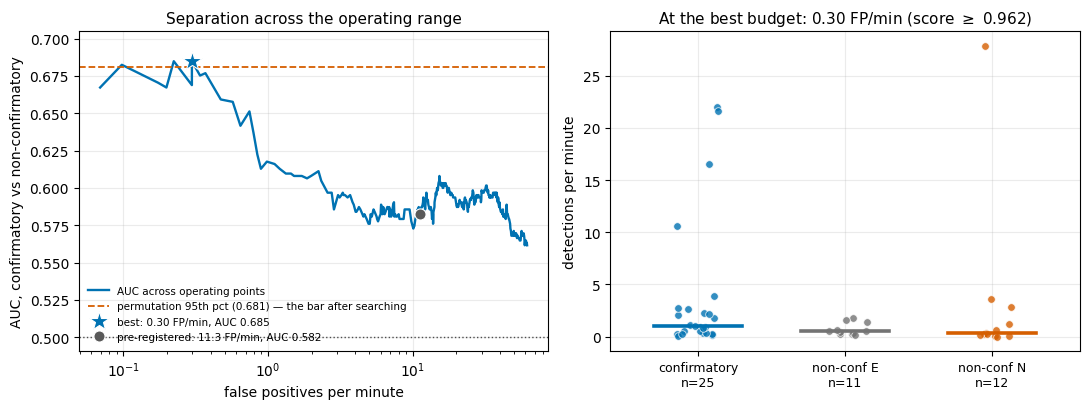

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ok = fp > 0
axes[0].plot(fp[ok], aucs[ok], color=COL[1], lw=1.7, label='AUC across operating points')
axes[0].axhline(np.percentile(mx, 95), ls='--', color=COL[0], lw=1.3,
                label=f'permutation 95th pct ({np.percentile(mx, 95):.3f}) — the bar after searching')
axes[0].axhline(.5, ls=':', color='0.3', lw=1)
axes[0].plot(fp[k], aucs[k], '*', ms=15, color=COL[1], mec='white', mew=.8, zorder=5,
             label=f'best: {fp[k]:.2f} FP/min, AUC {aucs[k]:.3f}')
axes[0].plot(fp[pre], aucs[pre], 'o', ms=8, color='0.35', mec='white', mew=.8, zorder=5,
             label=f'pre-registered: {fp[pre]:.1f} FP/min, AUC {aucs[pre]:.3f}')
axes[0].set_xscale('log'); axes[0].set_xlabel('false positives per minute')
axes[0].set_ylabel('AUC, confirmatory vs non-confirmatory')
axes[0].set_title('Separation across the operating range', fontsize=11)
axes[0].legend(fontsize=7.5, frameon=False, loc='lower left')
axes[0].set_ylim(top=aucs.max() + .02)

gen = np.random.default_rng(rng_seed)
CG = {'confirmatory': COL[1], 'non-conf E': '0.45', 'non-conf N': COL[0]}
for j, (g, c) in enumerate(CG.items()):
    v = x[mask[g]]
    axes[1].scatter(j + gen.uniform(-.15, .15, len(v)), v, s=30, alpha=.8, lw=.6,
                    color=c, edgecolor='white', zorder=3)
    axes[1].plot([j - .3, j + .3], [np.median(v)] * 2, color=c, lw=2.6, zorder=4)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels([f'{g}\nn={mask[g].sum()}' for g in CG], fontsize=9)
axes[1].set_xlim(-.6, 2.6); axes[1].set_ylabel('detections per minute')
axes[1].set_title(f'At the best budget: {fp[k]:.2f} FP/min (score $\\geq$ {ts[k]:.3f})', fontsize=11)
for ax in axes:
    ax.grid(alpha=.25); ax.set_axisbelow(True)
fig.tight_layout(); fig.savefig(FIGS / 'recording_level_best_budget.png', dpi=800, bbox_inches='tight')
plt.show()

## 12. Reporting checklist

`recording_level_evaluation.md` closes with a minimal reporting checklist. The cell below fills it from
the values computed above rather than restating them in prose, so it cannot go stale if the CSVs are
replaced with a larger sample — copy its output into report.md.

In [21]:
p_rate, p_top = summarise(rec['rate']), summarise(rec[f'top{TOP_N}'])
bg = summarise(rec.background_uv)
front = summarise(rec.events_min)
lines = [
    f"n per group            : {(y==1).sum()} confirmatory / {(y==0).sum()} non-confirmatory "
    f"({'BELOW' if min((y==1).sum(), (y==0).sum()) < 30 else 'meets'} the 30/group floor)",
    f"duration               : conf {rec.loc[y==1,'duration_s'].median()/60:.1f} min "
    f"[{rec.loc[y==1,'duration_s'].min()/60:.1f}-{rec.loc[y==1,'duration_s'].max()/60:.1f}], "
    f"non-conf {rec.loc[y==0,'duration_s'].median()/60:.1f} min "
    f"[{rec.loc[y==0,'duration_s'].min()/60:.1f}-{rec.loc[y==0,'duration_s'].max()/60:.1f}]",
    f"threshold              : {THR}, fixed in advance (pilot.py), not re-chosen; AUC across "
    f"{sens.threshold.min()}-{sens.threshold.max()} spans {sens.AUC.min():.3f}-{sens.AUC.max():.3f}",
    f"PRIMARY detections/min : AUC {p_rate['AUC']:.3f} [{p_rate['lo']:.3f}, {p_rate['hi']:.3f}], "
    f"Mann-Whitney p {p_rate['p']:.3g}, r_rb {p_rate['r_rb']:+.3f}",
    f"mean top-{TOP_N} (report.md) : AUC {p_top['AUC']:.3f} [{p_top['lo']:.3f}, {p_top['hi']:.3f}], "
    f"Mann-Whitney p {p_top['p']:.3g}, r_rb {p_top['r_rb']:+.3f}",
    f"front-end control      : events/min AUC {front['AUC']:.3f} (chance = L3 is doing the separating)",
    f"amplitude confound     : background_uv alone AUC {bg['AUC']:.3f}; "
    f"rho with top-{TOP_N} {spearmanr(rec.background_uv, rec[f'top{TOP_N}']).statistic:+.3f}",
    f"clustering             : {rec.subject.nunique()} subjects for {len(rec)} recordings; "
    f"sites in one group only: {sorted(set(rec.site) - set(shared.site))}",
    "limits to state         : (1) group separation does not show the detector fires ON the IEDs; "
    "(2) non-confirmatory contamination biases toward the null; "
    "(3) exploratory summaries in section 8 are not the headline",
]
print('\n'.join('- ' + l for l in lines))

- n per group            : 25 confirmatory / 25 non-confirmatory (BELOW the 30/group floor)
- duration               : conf 24.1 min [20.1-49.5], non-conf 21.2 min [20.0-30.3]
- threshold              : 0.766, fixed in advance (pilot.py), not re-chosen; AUC across 0.5-0.95 spans 0.574-0.651
- PRIMARY detections/min : AUC 0.582 [0.419, 0.741], Mann-Whitney p 0.161, r_rb +0.165
- mean top-10 (report.md) : AUC 0.715 [0.563, 0.858], Mann-Whitney p 0.00466, r_rb +0.430
- front-end control      : events/min AUC 0.483 (chance = L3 is doing the separating)
- amplitude confound     : background_uv alone AUC 0.640; rho with top-10 +0.354
- clustering             : 42 subjects for 50 recordings; sites in one group only: ['S02', 'S06']
- limits to state         : (1) group separation does not show the detector fires ON the IEDs; (2) non-confirmatory contamination biases toward the null; (3) exploratory summaries in section 8 are not the headline
